---
title: Linear Regression
author: Andrei Akopian
date: 2026-02-14
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

Baseline linear regression for unmixing.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn

In [31]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[1]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [32]:
DATA_FILEPATH = "../../data/isprs_26_new.csv"

In [33]:
df = helper_functions.open_file(DATA_FILEPATH)
fractions, nr900to1690_raw = helper_functions.take_subset(df,start=900,end=1690)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/isprs_26_new.csv'

# Naive Linear Regression

A naive linear regression, without adjusting to the specifics of the dataset in anyway.

In [22]:
nr900to1690

,900,910,920,930,940,950,960,970,980,990,...,1600,1610,1620,1630,1640,1650,1660,1670,1680,1690
0,0.093095,0.093828,0.094778,0.094742,0.095051,0.095950,0.097076,0.098382,0.099371,0.100335,...,0.120311,0.121864,0.123260,0.124360,0.125104,0.125603,0.125675,0.125429,0.125154,0.124856
1,0.088354,0.089189,0.090252,0.090415,0.090489,0.091587,0.092862,0.094439,0.095560,0.096685,...,0.122838,0.124489,0.126003,0.127352,0.128096,0.128656,0.128811,0.128685,0.128491,0.128149
2,0.093396,0.094172,0.095228,0.095079,0.095084,0.096111,0.097456,0.099121,0.100251,0.101427,...,0.121022,0.122454,0.123794,0.124945,0.125665,0.126225,0.126318,0.126392,0.126209,0.125802
3,0.094951,0.095699,0.096708,0.096523,0.096384,0.097368,0.098659,0.100390,0.101512,0.102718,...,0.118835,0.120188,0.121545,0.122743,0.123500,0.123926,0.124027,0.123964,0.123767,0.123414
4,0.090222,0.090930,0.091972,0.091799,0.091476,0.092552,0.093983,0.095822,0.097045,0.098294,...,0.123514,0.124581,0.125643,0.126533,0.127095,0.127491,0.127770,0.127862,0.127836,0.127662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1718,0.139105,0.139518,0.140205,0.139858,0.137569,0.136490,0.133483,0.132250,0.131940,0.132598,...,0.066259,0.067885,0.069497,0.070830,0.071903,0.072050,0.071567,0.071503,0.071732,0.070915
1719,0.151876,0.152099,0.152561,0.152216,0.149255,0.147258,0.142719,0.140298,0.139603,0.140160,...,0.050990,0.052560,0.053985,0.055341,0.056187,0.056477,0.056177,0.055864,0.056443,0.055562
1720,0.150778,0.150948,0.151310,0.150897,0.148649,0.146415,0.141778,0.138971,0.138164,0.138607,...,0.053033,0.054611,0.056056,0.057392,0.058319,0.058620,0.058257,0.058178,0.058350,0.057772
1721,0.132445,0.133111,0.133729,0.134213,0.133185,0.132209,0.129426,0.128467,0.128530,0.129127,...,0.071503,0.073464,0.075182,0.076679,0.077894,0.078358,0.078111,0.078009,0.077903,0.077021


In [23]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690, fractions.to_numpy(), test_size=0.5, random_state=42)
naive_regression = sklearn.linear_model.LinearRegression()
naive_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Naive linear regression sticks outside of the [0, 1] range.

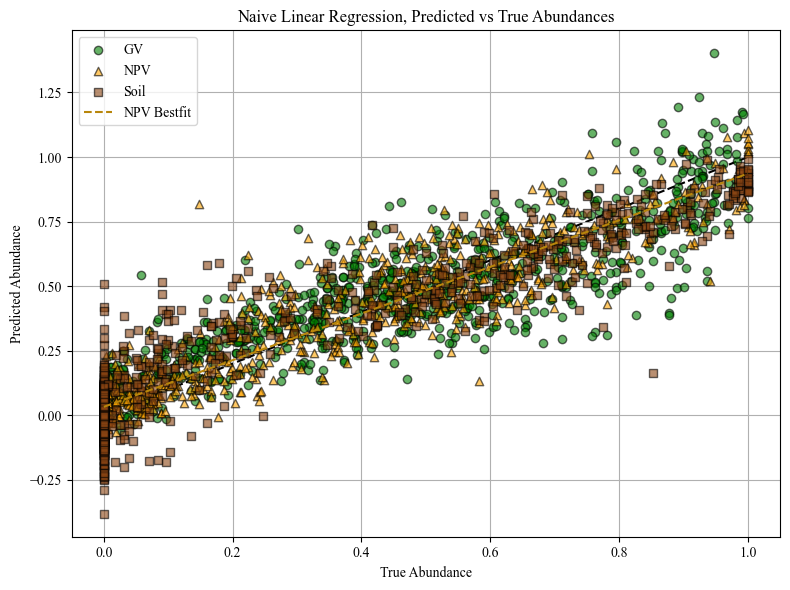

npv r^2 = 0.7644307192924437
gv r^2 = 0.8718118480669668
soil r^2 = 0.8728529738454758
mean r^2 = 0.8363651804016287


In [ ]:
ab_true_np_array = y_test
ab_predictions = naive_regression.predict(X_test)
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_predictions,
    model_name="Naive Linear Regression",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")

We clip the predicted abundances to [0,1] range, and visually confirm that the fractions add up roughly to 1.

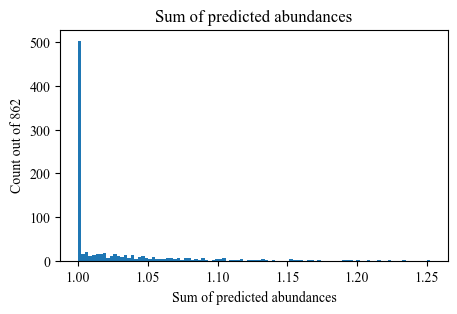

In [26]:
# | output: false
# | code-fold: true
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
helper_functions.simple_histogram(ab_clipped_predictions.sum(axis=1), title="Sum of predicted abundances", x_label="Sum of predicted abundances", y_label=f"Count out of {y_test.shape[0]}", bins=100)

Clipped prediction plot:

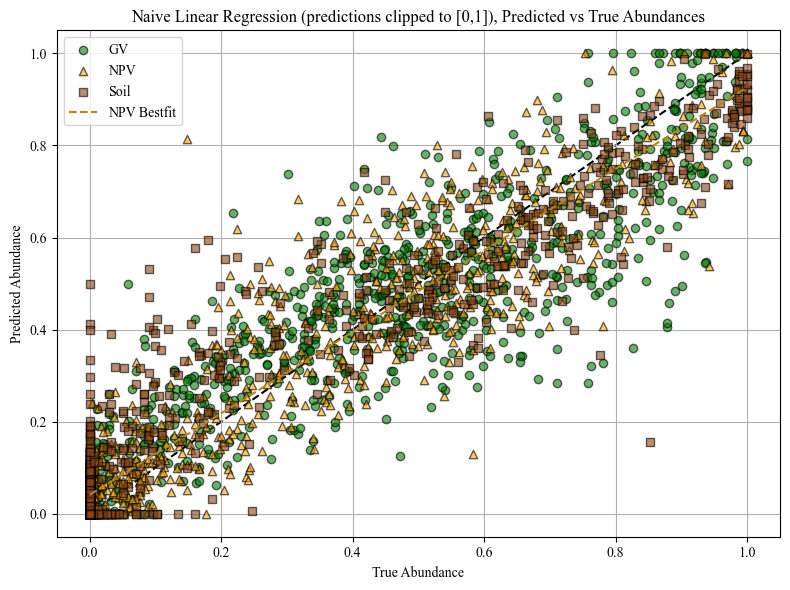

npv r^2 = 0.7748854105925236
gv r^2 = 0.8740945156981779
soil r^2 = 0.903522741558339
mean r^2 = 0.8508342226163469


In [10]:
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_clipped_predictions,
    model_name="Naive Linear Regression (predictions clipped to [0,1])",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipped_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")

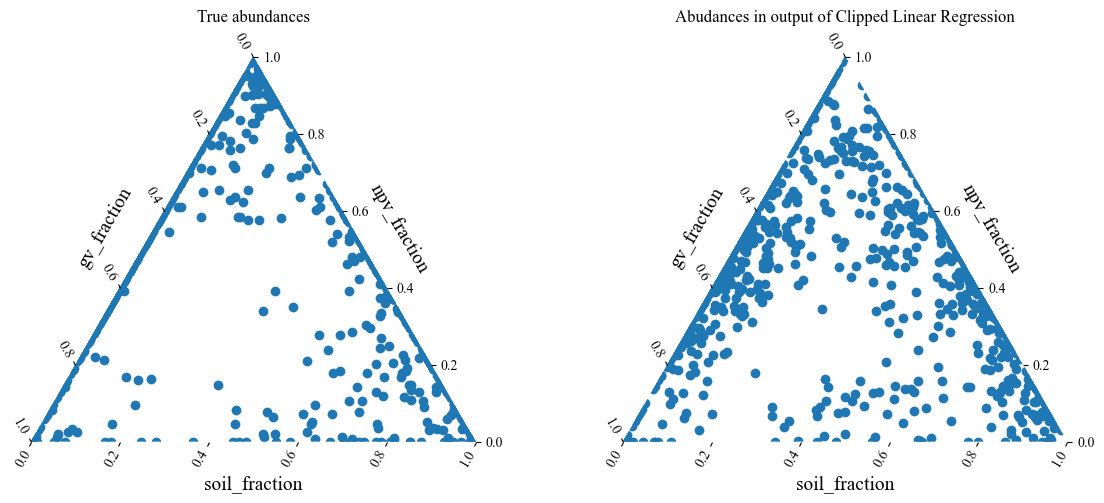

In [12]:
helper_functions.ternary_abundances(y_test, ab_clipped_predictions, model_name="Clipped Linear Regression")

# Better Linear Regression

The naive linear regression, has a number of drawbacks, such as forcing values to be clipped.

Also, naive linear regression ignored rows that were missing one of the 3 abundances. ([See `dataset_characterization.ipynb`](../characterization/dataset_characterization.ipynb))

This linear regression model will:
- train the abundanees separately, only using
- transform the results using a logit function into the [0, 1] range instead of clipping

In [13]:
logit = lambda x: scipy.special.logit((x-np.float64(0.5))*np.float64(0.90)+np.float64(0.5))
expit = scipy.special.expit

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1690, fractions, test_size=0.5, random_state=42)

def normalize(frame):
    return sklearn.preprocessing.normalize(frame,norm='l2',axis=1)

npv_indecies = {i for i, value in enumerate(df['has_npv']) if value}
gv_indecies = {i for i, value in enumerate(df['has_gv']) if value}
soil_indecies = {i for i, value in enumerate(df['has_soil']) if value}
training_indecies = set(X_train.index)

# fit regressions
npv_train_indecies = list(training_indecies.intersection(npv_indecies))
npv_regression = sklearn.linear_model.LinearRegression()
npv_train = logit(y_train.loc[npv_train_indecies]['npv_fraction'].to_numpy())
npv_regression.fit(normalize(X_train.loc[npv_train_indecies]), npv_train)

gv_train_indecies = list(training_indecies.intersection(gv_indecies))
gv_regression = sklearn.linear_model.LinearRegression()
gv_train = logit(y_train.loc[gv_train_indecies]['gv_fraction'].to_numpy())
gv_regression.fit(normalize(X_train.loc[gv_train_indecies]), gv_train)

soil_train_indecies = list(training_indecies.intersection(soil_indecies))
soil_regression = sklearn.linear_model.LinearRegression()
soil_train = logit(y_train.loc[soil_train_indecies]['soil_fraction'].to_numpy())
soil_regression.fit(normalize(X_train.loc[soil_train_indecies]), soil_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
testing_indecies = X_test.index
prediction_buffer = np.array([[0.0,0.0,0.0] for i in testing_indecies])
npv_preds = expit(npv_regression.predict(normalize(X_test)))
gv_preds = expit(gv_regression.predict(normalize(X_test)))
soil_preds = expit(soil_regression.predict(normalize(X_test)))

for i, index in enumerate(testing_indecies):
    if index in npv_indecies:
        prediction_buffer[i][0] = npv_preds[i]
    if index in gv_indecies:
        prediction_buffer[i][1] = np.float64(gv_preds[i])
    if index in soil_indecies:
        prediction_buffer[i][2] = np.float64(soil_preds[i])
        

In [27]:
# | output: false
# | code-fold: true
sums = np.sum(prediction_buffer, axis=1)
ab_clipnormed_predictions = np.array([prediction_buffer[i]/s for i, s in enumerate(sums)])
print(ab_clipnormed_predictions.sum(axis=1).min(), ab_clipnormed_predictions.sum(axis=1).max())

0.9999999999999998 1.0000000000000002


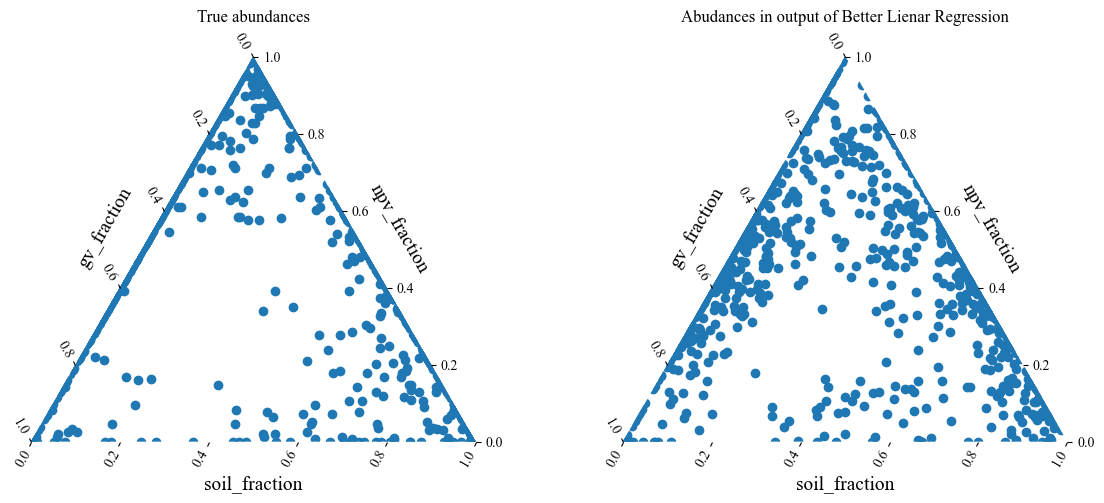

In [28]:
helper_functions.ternary_abundances(y_test, ab_clipped_predictions, model_name="Better Lienar Regression")

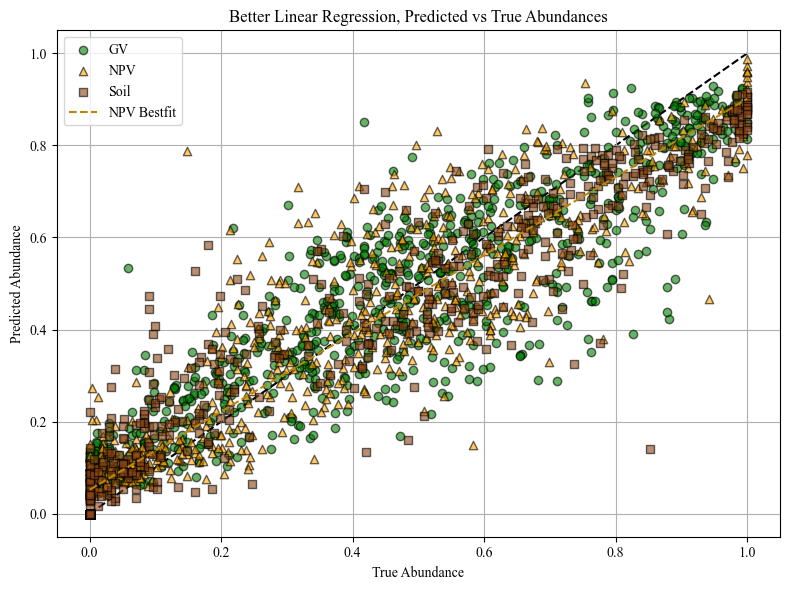

npv r^2 = 0.8119648124754021
gv r^2 = 0.862329722960615
soil r^2 = 0.9289759784084112
mean r^2 = 0.8677568379481427


In [25]:
helper_functions.plot_preds(
    ab_true=y_test.to_numpy(), 
    ab_pred=ab_clipnormed_predictions, 
    save_path="better_linear_regression.svg",
    model_name="Better Linear Regression"
)
slope, intercept, r, p, se = scipy.stats.linregress(y_test.to_numpy(), ab_clipnormed_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")